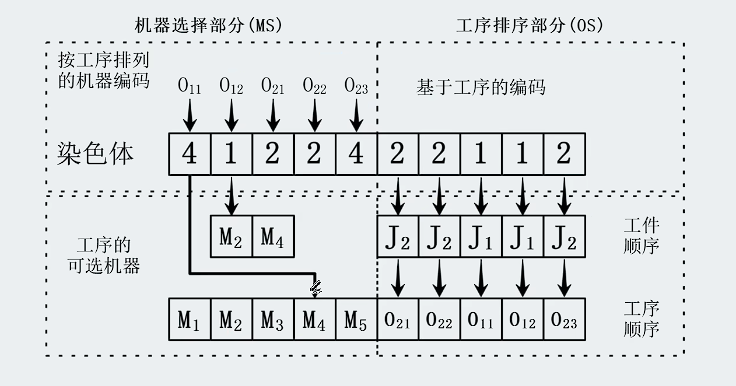

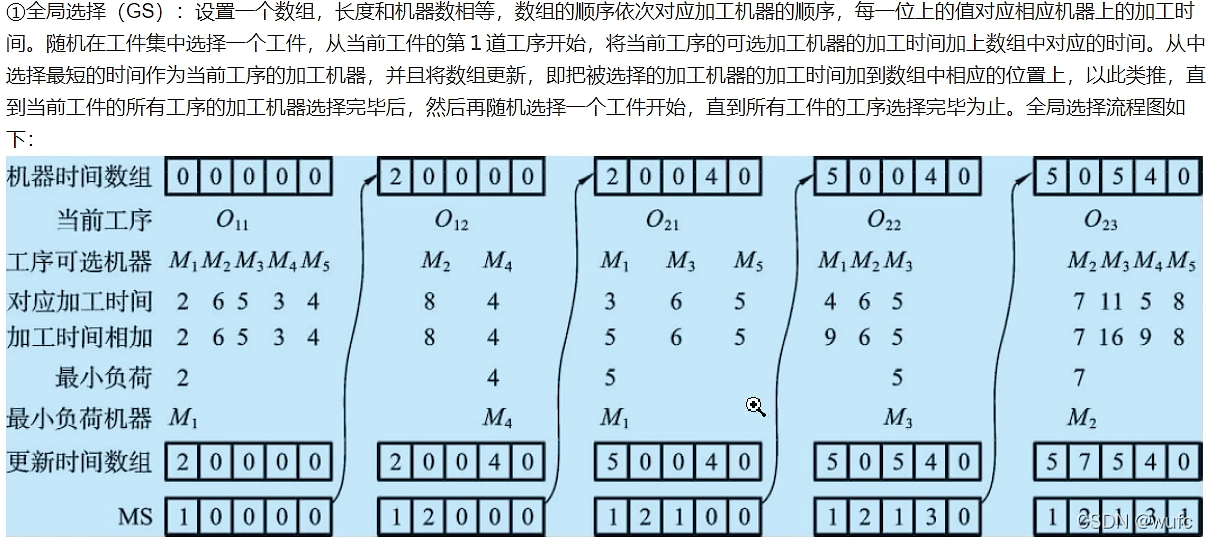

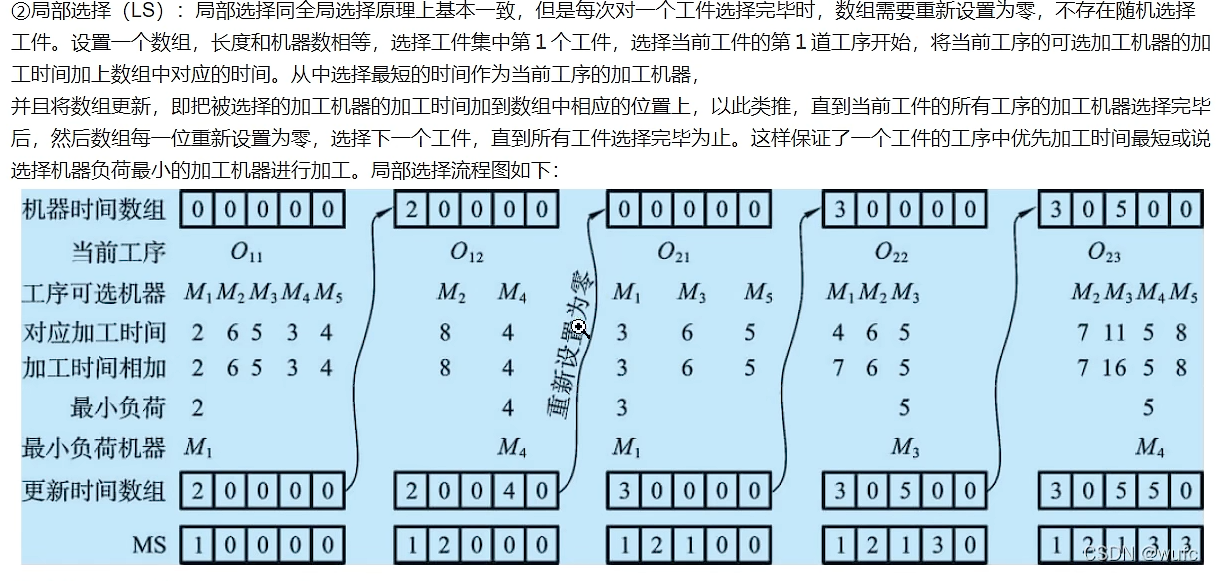

In [ ]:
import random
import numpy as np  
import matplotlib.pyplot as plt
import copy


In [2]:
J = [
    [[0,1,3,4], [1,2,3], [1,3,4]],
    [[0,2,3], [0,1,2,3,4], [0,1,2,4]],
    [[0,1,2,3,4], [1,2,3], [0,1,2,4]],
    [[0,1,2,3], [0,1,3,4], [0,1,2,4]]
]
P = [
    [[1,4,4,3], [6,4,3], [3,5,7]],
    [[5,5,3], [7,8,9,7,4], [6,3,8,5]],
    [[7,10,8,6,5], [4,5,3], [2,4,5,3]],
    [[5,5,6,4], [2,3,5,4], [4,3,4,6]]
]


In [ ]:

def GS(n,J,P):
    """
    Global Selection: choose machine with min load for each op
    n: number of machines
    J: machine list matrix
    P: processing time matrix
    return: MS list
    """
    MS=[]
    time_list=np.zeros(n)
    job_num=len(J)
    for i in range(job_num):
        job_list=J[i]
        for j in range(len(job_list)):
            min_time=float('inf')
            min_time_index=0
            min_time_machine=0
            machine_list=job_list[j]
            process_time_list=P[i][j]
            for m in range(len(machine_list)):
                temp_time = time_list[machine_list[m]] + process_time_list[m]
                if temp_time < min_time:
                    min_time = temp_time
                    min_time_index = m
                    min_time_machine = machine_list[m]
            MS.append(min_time_index)
            time_list[min_time_machine] += process_time_list[min_time_index]
    return MS


[0, 0, 0, 2, 0]

In [1]:



def choice(fitness,k=3,pool=40):
    '''
    fitnee 适应度
    k 比较个数
    pool 选择池大小
    '''
    n=len(fitness)
    choice_index=[]
    for _ in range(pool):
        random_indices = random.sample(range(n), k)
        f_values = [fitness[i] for i in random_indices]
        min_f_value = min(f_values)
        choice_index.append(f_values.index(min_f_value))
    return choice_index

def cross_MS(A,B):
    '''
    A,B 两个父代个体
    '''
    job_num=len(A)
    random_numbers = random.sample(range(job_num), 2)
    rl,rr=min(random_numbers),max(random_numbers)
    return A[:rl]+B[rl:rr+1]+A[rr+1:],B[:rl]+A[rl:rr+1]+B[rr+1:]


def cross_OS(A,B):
    '''
    A,B 两个父代个体

    原理：选择一个子集S1，S1中的元素表示工件，保持选中工件的位置在原区域保持不变，其余按另一个父代个体的顺序填充
    '''
    chromosome_length = len(A)
    job_id=list(set(A))
    job_num=len(job_id)
    #确保抽取的数量不为0，同时不等于列表长度
    while True:
        num_to_extract=random.randint(1,job_num-1)
        if num_to_extract>0 and num_to_extract<job_num:
            break

    S1=random.sample(job_id,num_to_extract)
    
    afinal=[None for _ in range(chromosome_length)]
    temp_B=[item for item in B if item not in S1]
    K=0
    for i in range(chromosome_length):
        if A[i] in S1:
            afinal[i]=A[i]
            K+=1
        else:
            afinal[i]=temp_B[K]
            K+=1

    bfinal=[None for _ in range(chromosome_length)]
    temp_B=[item for item in B if item not in S1]
    K=0
    for i in range(chromosome_length):
        if B[i] in S1:
            bfinal[i]=B[i]
            K+=1
        else:
            bfinal[i]=temp_B[K]
            K+=1
    return afinal,bfinal

def cross(A,B):
    job_num_all=int(len(A)/2)
    MS_A,OS_A=cross_MS(A[:job_num_all],A[job_num_all:])
    MS_B,OS_B=cross_MS(B[:job_num_all],B[job_num_all:])
    MS_A,MS_B=cross_OS(MS_A,MS_B)
    OS_A,OS_B=cross_OS(OS_A,OS_B)
    return MS_A+OS_A,MS_B+OS_B


In [ ]:


def mutation_OS(Ind):
    '''
    Ind 个体
    '''
    A=Ind.copy()
    n=len(A)
    idx1,idx2=random.sample(range(n),2)
    rl,rr=min(idx1,idx2),max(idx1,idx2)
    A[rl:rr]=A[rl:rr][::-1]
    return A

def mutation_MS(A,P):
    '''
    A 个体
    P 工件处理时间矩阵
    '''
    process_num=len(A)
    process_time=[item for sublist in P for item in sublist]
    r=np.random.rand(process_num)
    random_select=random.sample(range(process_num),r)
    for i in random_select:
        A[i]=process_time[i].index(min(process_time[i]))
    return A

def mutation(Ind,P):
    process_num=int(len(Ind)/2)
    MS =mutation_MS(Ind[:process_num],P)
    OS =mutation_OS(Ind[process_num:])
    return MS+OS



In [ ]:
import matplotlib.patches as mpatches
def GS_select(n, J, P):
    """
    全局选择：为每道工序选择当前负载最小的机器
    n: 机器数量
    J: 可选机器列表
    P: 加工时间列表
    返回: MS列表 (每道工序选中的机器在可选列表中的索引)
    """
    MS = []
    time_list = [0] * n
    for job_idx in range(len(J)):
        for op_idx in range(len(J[job_idx])):
            machine_list = J[job_idx][op_idx]
            p_list = P[job_idx][op_idx]
            min_time = float("inf")
            min_m_idx = 0
            for m_idx in range(len(machine_list)):
                temp_time = time_list[machine_list[m_idx]] + p_list[m_idx]
                if temp_time < min_time:
                    min_time = temp_time
                    min_m_idx = m_idx
            MS.append(min_m_idx)
            time_list[machine_list[min_m_idx]] += p_list[min_m_idx]
    return MS

def createInd(J, P, use_GS=True):
    """创建FJSP个体（MS + OS 染色体）"""
    if use_GS:
        n_m = max(max(m_list) for job in J for m_list in job) + 1
        MS = GS_select(n_m, J, P)
    else:
        MS = []
        for job in J:
            for m_list in job:
                MS.append(random.randint(0, len(m_list) - 1))

    OS = []
    job_ops = [len(job) for job in J]
    Jm = job_ops.copy()
    while not all(o == 0 for o in Jm):
        I = random.randint(0, len(Jm) - 1)
        if Jm[I] != 0:
            OS.append(I)
            Jm[I] -= 1
    return MS + OS

def createPop(J, P, popSize):
    """创建种群，第一个个体用GS初始化"""
    pop = []
    for i in range(popSize):
        pop.append(createInd(J, P, use_GS=(i == 0)))
    return pop

def decode(chromosome, J, P):
    """
    解码FJSP染色体
    返回: (schedule, makespan)
    schedule: [(job, op_idx, machine, start, end), ...]
    """
    n_ops = sum(len(job) for job in J)
    MS = chromosome[:n_ops]
    OS = chromosome[n_ops:]

    op_map = {}
    global_idx = 0
    for job_idx in range(len(J)):
        for op_idx in range(len(J[job_idx])):
            op_map[(job_idx, op_idx)] = global_idx
            global_idx += 1

    job_step = [0] * len(J)
    job_end_time = [0] * len(J)
    machine_num = max(max(m_list) for job in J for m_list in job) + 1
    machine_end_time = [0] * machine_num
    schedule = []

    for job in OS:
        op_idx = job_step[job]
        global_op_idx = op_map[(job, op_idx)]
        m_idx = MS[global_op_idx]
        machine = J[job][op_idx][m_idx]
        p_time = P[job][op_idx][m_idx]
        start_time = max(job_end_time[job], machine_end_time[machine])
        end_time = start_time + p_time
        schedule.append((job, op_idx, machine, start_time, end_time))
        job_step[job] += 1
        job_end_time[job] = end_time
        machine_end_time[machine] = end_time
    makespan = max(job_end_time)
    return schedule, makespan

def cross_fjsp(A, B):
    """
    FJSP交叉：MS用两点交叉 + OS用POX交叉
    """
    n_ops = len(A) // 2
    # MS两点交叉
    MS_A, MS_B = A[:n_ops], B[:n_ops]
    rl, rr = sorted(random.sample(range(n_ops), 2))
    new_MS1 = list(MS_A[:rl]) + list(MS_B[rl:rr+1]) + list(MS_A[rr+1:])
    new_MS2 = list(MS_B[:rl]) + list(MS_A[rl:rr+1]) + list(MS_B[rr+1:])

    # OS: POX交叉
    OS_A, OS_B = list(A[n_ops:]), list(B[n_ops:])
    job_set = list(set(OS_A))
    n_jobs = len(job_set)
    if n_jobs <= 1:
        return A, B
    num_extract = random.randint(1, n_jobs - 1)
    S1 = set(random.sample(job_set, num_extract))

    child_OS1 = [None] * len(OS_A)
    temp = [item for item in OS_B if item not in S1]
    idx = 0
    for i in range(len(OS_A)):
        if OS_A[i] in S1:
            child_OS1[i] = OS_A[i]
        else:
            child_OS1[i] = temp[idx]
            idx += 1

    child_OS2 = [None] * len(OS_B)
    temp = [item for item in OS_A if item not in S1]
    idx = 0
    for i in range(len(OS_B)):
        if OS_B[i] in S1:
            child_OS2[i] = OS_B[i]
        else:
            child_OS2[i] = temp[idx]
            idx += 1

    return new_MS1 + child_OS1, new_MS2 + child_OS2

def mutation_fjsp(Ind, J, P, pm=0.1):
    """
    FJSP变异：MS随机选机器 + OS逆序变异
    """
    n_ops = sum(len(job) for job in J)
    MS = list(Ind[:n_ops])
    OS = list(Ind[n_ops:])

    # MS变异：以概率pm随机换一台可用机器
    op_idx = 0
    for job_idx in range(len(J)):
        for op in range(len(J[job_idx])):
            if random.random() < pm:
                MS[op_idx] = random.randint(0, len(J[job_idx][op]) - 1)
            op_idx += 1

    # OS变异：逆序
    if random.random() < pm:
        idx1, idx2 = random.sample(range(len(OS)), 2)
        rl, rr = min(idx1, idx2), max(idx1, idx2)
        OS[rl:rr] = OS[rl:rr][::-1]

    return MS + OS


In [ ]:
def draw_gantt(schedule, J, P, title="FJSP Gantt Chart"):
    """绘制FJSP甘特图"""
    n_jobs = len(J)
    machine_num = max(max(m_list) for job in J for m_list in job) + 1
    colors = plt.cm.tab10(np.linspace(0, 1, n_jobs))
    fig, ax = plt.subplots(figsize=(14, 7))
    machine_ops = {i: [] for i in range(machine_num)}
    for job, op_idx, machine, start, end in schedule:
        machine_ops[machine].append((job, op_idx, start, end))
    for machine in range(machine_num):
        for job, op_idx, start, end in machine_ops[machine]:
            ax.barh(machine, end - start, left=start, height=0.6,
                    color=colors[job], edgecolor="black", linewidth=1)
            ax.text((start + end) / 2, machine, f"J{job}O{op_idx}",
                    ha="center", va="center", fontsize=9, fontweight="bold")
    ax.set_yticks(range(machine_num))
    ax.set_yticklabels([f"M{i}" for i in range(machine_num)])
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Machine", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis="x", alpha=0.3)
    patches = [mpatches.Patch(color=colors[i], label=f"Job {i}") for i in range(n_jobs)]
    ax.legend(handles=patches, loc="upper right")
    plt.tight_layout()
    plt.show()

def print_schedule(schedule):
    """打印调度方案"""
    print("Job | Op | Machine | Start | End")
    print("---" * 8)
    for job, op_idx, machine, start, end in schedule:
        print(f" J{job} | {op_idx} |   M{machine}  |  {start:.0f}  | {end:.0f}")
    makespan = max(end for _, _, _, _, end in schedule)
    print(f"\nMakespan = {int(makespan)}")


In [ ]:
def selection(fitness, k=3, pool=None):
    """锦标赛选择（返回种群中的实际索引）"""
    if pool is None:
        pool = len(fitness)
    n = len(fitness)
    result = []
    for _ in range(pool):
        random_indices = random.sample(range(n), k)
        best_idx = random_indices[0]
        for idx in random_indices[1:]:
            if fitness[idx] < fitness[best_idx]:
                best_idx = idx
        result.append(best_idx)
    return result

def GA_FJSP(J, P, popSize=50, generations=100, pc=0.8, pm=0.1):
    """GA求解FJSP主函数"""
    n_jobs = len(J)
    n_ops = sum(len(job) for job in J)
    machine_num = max(max(m_list) for job in J for m_list in job) + 1
    print(f"FJSP实例: {n_jobs}个Job, {n_ops}道工序, {machine_num}台机器")

    pop = createPop(J, P, popSize)
    best_makespan = float("inf")
    best_chromosome = None
    best_schedule = None
    best_history = []

    for gen in range(generations):
        fitness = []
        schedules = []
        for chrom in pop:
            schedule, makespan = decode(chrom, J, P)
            fitness.append(makespan)
            schedules.append(schedule)

        min_idx = int(np.argmin(fitness))
        gen_best = fitness[min_idx]
        best_history.append(gen_best)

        if gen_best < best_makespan:
            best_makespan = gen_best
            best_chromosome = pop[min_idx].copy()
            best_schedule = schedules[min_idx]

        selected_idx = selection(fitness, k=3, pool=popSize)
        selected_chroms = [pop[i] for i in selected_idx]

        new_pop = []
        i = 0
        while i < popSize:
            if i + 1 < popSize and random.random() < pc:
                c1, c2 = cross_fjsp(selected_chroms[i], selected_chroms[i+1])
                new_pop.append(c1)
                new_pop.append(c2)
                i += 2
            else:
                new_pop.append(selected_chroms[i].copy())
                i += 1

        for i in range(len(new_pop)):
            new_pop[i] = mutation_fjsp(new_pop[i], J, P, pm)

        pop = new_pop

        if (gen + 1) % 20 == 0 or gen == 0:
            print(f"Generation {gen+1:4d}: Best = {gen_best:3d}, Global Best = {best_makespan:3d}")

    print(f"\nFinal Results:")
    print(f"Best Makespan = {best_makespan}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(best_history, "b-", linewidth=1.5)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Makespan")
    ax1.set_title("Convergence Curve")
    ax1.grid(alpha=0.3)

    draw_gantt(best_schedule, J, P, title=f"Best Schedule (Makespan={best_makespan})")
    print_schedule(best_schedule)

    return best_chromosome, best_makespan, best_schedule


In [ ]:
# Kacem 4x5 benchmark (4 jobs, 5 machines, partial flexibility, optimal makespan=11)
J = [
    [[0,1,3,4], [1,2,3], [1,3,4]],
    [[0,2,3], [0,1,2,3,4], [0,1,2,4]],
    [[0,1,2,3,4], [1,2,3], [0,1,2,4]],
    [[0,1,2,3], [0,1,3,4], [0,1,2,4]]
]
P = [
    [[1,4,4,3], [6,4,3], [3,5,7]],
    [[5,5,3], [7,8,9,7,4], [6,3,8,5]],
    [[7,10,8,6,5], [4,5,3], [2,4,5,3]],
    [[5,5,6,4], [2,3,5,4], [4,3,4,6]]
]

n_jobs = len(J)
n_ops = sum(len(job) for job in J)
machine_num = max(max(m_list) for job in J for m_list in job) + 1
print(f"Job数量: {n_jobs}")
print(f"总工序数: {n_ops}")
print(f"机器数量: {machine_num}")
print(f"已知最优 makespan = 11")

best_chromosome, best_makespan, best_schedule = GA_FJSP(
    J, P,
    popSize=100,
    generations=200,
    pc=0.8,
    pm=0.1
)
